In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import os

In [2]:
plt.style.use('default')

plt.rcParams['savefig.transparent'] = False
plt.rcParams['savefig.facecolor'] = 'white'
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'

# Phase 1: Outlier Detection

## **Objective:**
Identify and remove abnormal transactions in the Online Sales dataset to prevent noise from affecting subsequent RFM analysis.

## **Input data**
`Cleaned_Online_Sales.csv`

Outlier detection was applied only to the Online Sales dataset,
as it directly represents transaction-level data used in RFM analysis.

Other datasets were not subjected to outlier removal since they do not contain transactional values relevant to this analysis.

## **Methodology:**
Compute the actual transaction value for each record:
1. Transaction_Value = `(Quantity × Avg_Price) + Delivery_Charges`
2. Convert the `Transaction_Date` column to an appropriate datetime format.
3. Apply the IQR (Interquartile Range) method in combination with `boxplot` visualization to detect and remove values that fall outside the acceptable range (outliers).

## **Output Data**

The output dataset is an enhanced version of the original Online Sales data, stored as `Online_Sales_with_VIP.csv` in the processed data directory.

A new feature, `Customer_Type`, is introduced to categorize transactions into two groups:
- **VIP (Whales):** transactions with `Transaction_Value` exceeding the IQR upper bound
- **Regular:** standard transactions within the normal range

This transformation retains all observations while enriching the dataset with meaningful segmentation based on transaction value.


In [3]:
# Load data
sales_df = pd.read_csv('../data/cleaned_data/Cleaned_Online_Sales.csv')

# Convert datetime
sales_df['Transaction_Date'] = pd.to_datetime(sales_df['Transaction_Date'])

# Create Transaction_Value
sales_df['Transaction_Value'] = (sales_df['Quantity'] * sales_df['Avg_Price']) + sales_df['Delivery_Charges']

print(f"Total number of transactions (before outlier removal): {len(sales_df)}")
sales_df.head(2)

Total number of transactions (before outlier removal): 52924


,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,Transaction_Value
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,160.21
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,160.21


**Outlier Threshold Determination Using IQR**
Outliers are identified using the IQR method, where values outside the range
`[Q1 - 1.5×IQR, Q3 + 1.5×IQR]` are considered abnormal.

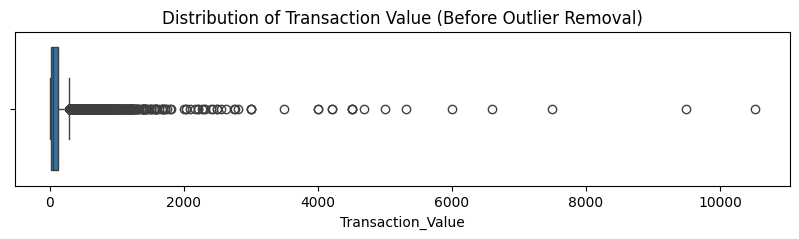

Upper Bound value: 293.790
Lower bound value: -144.930


In [4]:
Q1 = sales_df['Transaction_Value'].quantile(0.25)
Q3 = sales_df['Transaction_Value'].quantile(0.75)
IQR: float = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# boxplot before remove outlier
plt.figure(figsize=(10, 2))
sns.boxplot(x=sales_df['Transaction_Value'])
plt.title('Distribution of Transaction Value (Before Outlier Removal)')

# save img as boxplot_before_outlier.png
output_folder = "../assets/images"
os.makedirs(output_folder, exist_ok=True)
file_path = os.path.join(output_folder, "boxplot_before_outlier.png")
plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()

# Show the outlier
print(f"Upper Bound value: {upper_bound:.3f}")
print(f"Lower bound value: {lower_bound:.3f}")

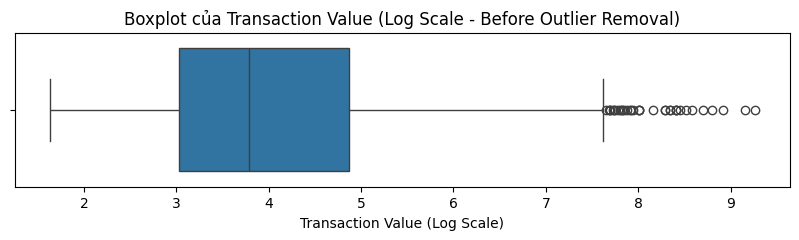

In [5]:
# For better visualization the distribution of typical customer behavior,
# the data is presented using a log-transformed scale.
plt.figure(figsize=(10, 2))
sns.boxplot(x=np.log1p(sales_df['Transaction_Value']))
plt.title('Boxplot của Transaction Value (Log Scale - Before Outlier Removal)')
plt.xlabel('Transaction Value (Log Scale)')
ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.ticklabel_format(style='plain', axis='x')

# save img as boxplot_before_outlier(log_scale).png
output_folder = "../assets/images"
os.makedirs(output_folder, exist_ok=True)
file_path = os.path.join(output_folder, "boxplot_before_outlier(scale).png")
plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()

## Outlier Interpretation and Validation

The distribution of Transaction_Value is highly right-skewed, with a substantial number of extreme values forming a long tail.

To better understand these extreme values, further analysis was conducted by examining both their proportion within the dataset and their contribution to total revenue.


In [6]:
total_revenue = sales_df['Transaction_Value'].sum()
outliers = sales_df[
    (sales_df['Transaction_Value'] > upper_bound) |
    (sales_df['Transaction_Value'] < lower_bound)
]
outlier_revenue = outliers['Transaction_Value'].sum()
outlier_revenue_ratio = (outlier_revenue / total_revenue) * 100
outlier_ratio = len(outliers) / len(sales_df) * 100
print("\n--- OUTLIER REVENUE IMPACT ---")
print(f"Outlier Ratio: {outlier_ratio:.3f}%")
print(f"Total Revenue: {total_revenue:,.3f}")
print(f"Outlier Revenue: {outlier_revenue:,.3f}")
print(f"Revenue Ratio: {outlier_revenue_ratio:.3f}%")


--- OUTLIER REVENUE IMPACT ---
Outlier Ratio: 7.156%
Total Revenue: 5,227,429.690
Outlier Revenue: 1,742,349.530
Revenue Ratio: 33.331%


## Outlier Revenue Impact Analysis

The analysis reveals that outliers, although representing only a small proportion of total transactions (7.156%), contribute a disproportionately large share of total revenue (33.331%).

This indicates a strong revenue concentration among a small group of high-value transactions, consistent with a Pareto-like distribution.

Rather than treating these observations as noise, they are identified as economically significant and reinterpreted as high-value (VIP) customer behavior.

By preserving and explicitly labeling these transactions, the dataset captures critical revenue-driving patterns, enabling more effective downstream analysis, particularly in customer segmentation and RFM modeling.

In [7]:
sales_df['Customer_Type'] = np.where(sales_df['Transaction_Value'] > upper_bound, 'VIP (Whales)', 'Regular')
print(sales_df['Customer_Type'].value_counts())
sales_df.head(2)

# Save Online_Sales_with_VIP.csv in data/processed
output_folder = "../data/processed"
os.makedirs(output_folder, exist_ok=True)

output_path = os.path.join(output_folder, "Online_Sales_with_VIP.csv")

sales_df.to_csv(output_path, index=False)

Customer_Type
Regular         49137
VIP (Whales)     3787
Name: count, dtype: int64
